<a href="https://colab.research.google.com/github/valeriasalazar1-glitch/P2_2025_2_inf2/blob/main/Metodos_de_Regresi%C3%B3n_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabajo independiente sobre métodos de regresión lineal y múltiple

**Integrantes:**

- Jean Carlos Suarez Hernandez

- Valeria Salazar Ibargüen

- Diego Mario Salamanca Cardenas


**Punto 1: Método de regresión líneal**

Primero conectamos el entorno de colab al Drive
seguido de importar las librerias necesarias para análisis y visualización.

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Lo primero es cargar la ruta de acceso en el drive para traer los datos a los cuales queremos hacer el análisis

Index(['Número de fila', 'X', 'y'], dtype='object')


**Librería.**

Se carga la libreria sklearn.linear_model y con ello poder implementar la función de regresión lineal la cual modela la relación entre una variable dependiente y una o más independientes
ajustando una línea recta que mejor ajuste a los datos.
Su objetivo principal es predecir resultados futuros y entender la relación entre variables.

**Método FIT.**

Su función es entrenar el modelo este proceso consiste en alimentar el algoritmo utilizando las variables independientes y la etiqueta para que aprenda los patrones subyacentes. Internamente este método minimiza el error entre sus predicciones y los valores de etiqueta

In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression(fit_intercept=True)
modelo. fit (X,Y)

LinearRegression()

**Coeficientes del modelo**

Son valores quie definen la relación entre variables.

La ecuación Y = b0 + b1X

b1. expresa la pendiente de la recta lo cual es el cambio en Y(var. dependiente) por unidad de X(var. independientes)

b0. es la ordenada al origen es el valor esperado de Y cuando todas las variables independientes son cero

In [ ]:
beta0 = modelo.intercept_
betal = modelo.coef_
x_plot = np.linspace(58,97,20)
y_plot = betal + betal*x_plot

**Visualización**

Se configura la visualizacón de la gráfica  determinando cual es el eje x (x_plot) y cual el eje y (y_plot) definiendo tambien color, grosor de linea, fuentes y las leyendas

ax.scatter grafica sobre la línea negra los datos experimentales como un punto

/tmp/ipykernel_2308/2655398880.py:4: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter (X,Y, c=[245/255, 149/255, 39/255], label="Datos reales")


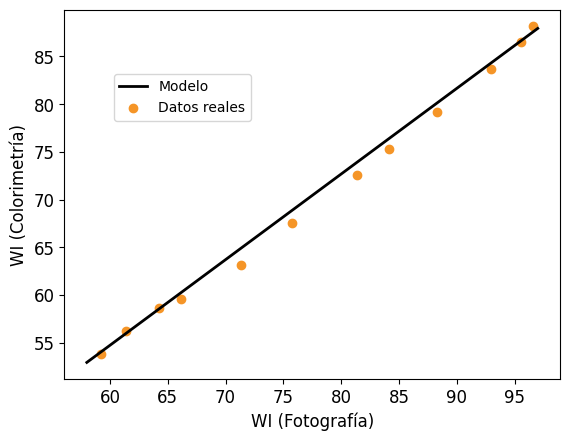

In [ ]:
fig, ax = plt.subplots()

ax.plot(x_plot, y_plot, c="k", lw=2, label="Modelo")
ax.scatter (X,Y, c=[245/255, 149/255, 39/255], label="Datos reales")

ax.set_ylabel("WI (Colorimetría)", fontname = "Arial", fontsize=12)
ax.set_xlabel("WI (Fotografía)", fontname="Arial", fontsize=12)

plt.xticks(fontfamily = "Arial", fontsize=12)
plt.yticks(fontfamily = "Arial", fontsize=12)
ax.legend(prop={"family": "Arial", 'size' :10}, loc=(0.1,0.7), fontsize=12)

**2. Método de regresión múltiple.**

**Carga de datos:**

Se importa la librería pandas y se cargan los datos del archivo ‘diabetes.xlsx’

In [2]:
import pandas as pd
df = pd. read_excel('diabetes.xlsx')

**Análisis de correlación:**
La correlación permite guiar la selección de variables regresoras. Se construye una matriz de correlación ayuda a determinar cómo se relacionan o dependen entre sí dos o más variables. En esta podemos interpretar el siguiente componente clave:

**Diagonal principal:** En la digonal siempre están contenidos valores de 1, pues cada variable está perfectamente correlacionada consigo misma.
**Interpretación:**
- *Valor cercano a 1:* Si una variable aumenta, la otra también
- *⁠Valor cercano a -1:* Si una variable aumenta la otra disminuye
- *⁠Valor cercano a 0:* Relación lineal débil o nula

In [3]:
print(df.head())
print(df.info())

   AGE  SEX   BMI     BP   S1     S2    S3   S4      S5  S6    Y
0   59    2  32.1  101.0  157   93.2  38.0  4.0  4.8598  87  151
1   48    1  21.6   87.0  183  103.2  70.0  3.0  3.8918  69   75
2   72    2  30.5   93.0  156   93.6  41.0  4.0  4.6728  85  141
3   24    1  25.3   84.0  198  131.4  40.0  5.0  4.8903  89  206
4   50    1  23.0  101.0  192  125.4  52.0  4.0  4.2905  80  135
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int6

**Matriz de correlación**

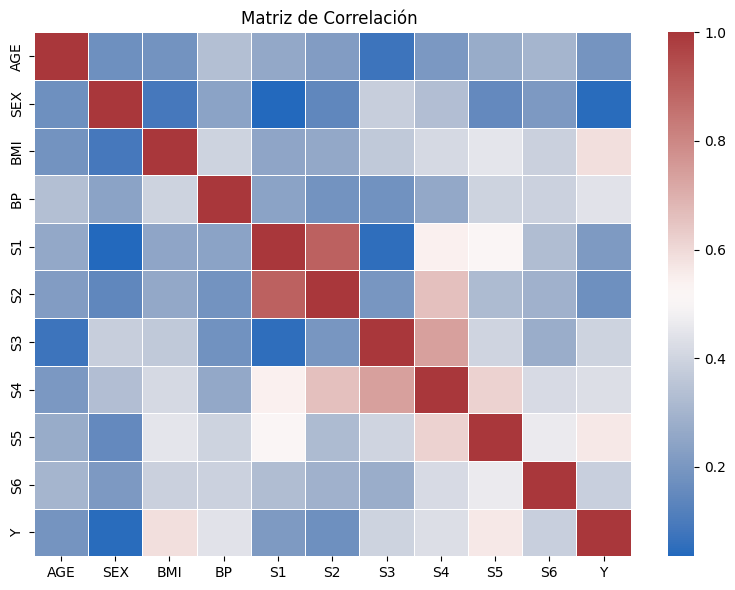

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
plt.title("Matriz de Correlación ")
#no importa si la correlación es positiva o negativa, entonces se puede graficar abs
sns.heatmap(abs(corr_matrix.values), cmap='vlag', fmt=".2f", linewidths=0.5,xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.tight_layout()

LinearRegression, es una funcion que ajusta un modelo lineal con coeficientes w =(w1,..,wp) para minimizar la suma de los residuos al cuadrado entre los datos de entrada ('X') y los datos predecidos ('y')

**Parámetros**

*Intercepto:* Valor previsto de 'y' cuando las variables independientes son 0

**Modelo de efectos principales:**

In [8]:
y = df ['S2']
X = df[['S1', 'S4']]

from sklearn.linear_model import LinearRegression

modelo = LinearRegression(fit_intercept=True).fit(X,y)

la funcion *feature_names_in_* retorna el nombre de los features/columnas de las variables utilizadas para el entrenamiento de la regresion lineal

**Modelo con interacciones:**

In [13]:
from sklearn. pipeline import make_pipeline
from sklearn. preprocessing import PolynomialFeatures
from sklearn. linear_model import LinearRegression
# El modelo tendrá interacciones de grado 2, y debemos tener en la clase PoynomialFo #parámetro interction_only = True, para que solo incluya las interacciones, ya que #clase se usa para construir también modelos polinómicos, y de no estar en True esto
#el modelo incluiría potencias.
modelo = make_pipeline(PolynomialFeatures(degree= 2, interaction_only=True),LinearRegression()). fit(X,y)

In [14]:
beta0 = modelo._final_estimator.intercept_
coef = modelo._final_estimator.coef_
features = modelo.named_steps.polynomialfeatures.get_feature_names_out()
print(beta0)
print (coef)
print (features)

-43.13516453778186
[ 0.          0.71249681  7.8163286  -0.0100779 ]
['1' 'S1' 'S4' 'S1 S4']
